In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
ORANGE_LINE_DATA = "orange_line_merged.csv"

data = pd.read_csv(ORANGE_LINE_DATA)
data.head()

,trip_id,stop_id,stop_sequence,arrival_time_schedule,departure_time_schedule,direction_id_schedule,timestamp_collected_schedule,schedule_type_schedule,arrival_time_realtime,departure_time_realtime,status,direction_id_realtime,timestamp_collected_realtime,schedule_type_realtime,delay_minutes
0,70525422,70033,170,2025-11-05 14:56:00-05:00,2025-11-05 14:56:00-05:00,1,2025-11-05T14:55:04.295171-05:00,planned,2025-11-05 14:52:57-05:00,2025-11-05 14:54:16-05:00,NaN,1,2025-11-05T14:56:05.795084-05:00,realtime,-1.733333
1,70525422,70035,180,2025-11-05 15:00:00-05:00,2025-11-05 15:00:00-05:00,1,2025-11-05T14:55:04.295171-05:00,planned,2025-11-05 14:56:28-05:00,2025-11-05 14:57:27-05:00,NaN,1,2025-11-05T14:58:07.838004-05:00,realtime,-2.550000
2,70525430,70029,140,2025-11-05 14:56:00-05:00,2025-11-05 14:56:00-05:00,1,2025-11-05T14:55:04.295171-05:00,planned,2025-11-05 14:52:31-05:00,2025-11-05 14:53:27-05:00,NaN,1,2025-11-05T14:56:05.795084-05:00,realtime,-2.550000
3,70525430,70031,150,2025-11-05 14:58:00-05:00,2025-11-05 14:58:00-05:00,1,2025-11-05T14:55:04.295171-05:00,planned,2025-11-05 14:54:40-05:00,2025-11-05 14:55:43-05:00,NaN,1,2025-11-05T14:55:04.295171-05:00,realtime,-2.283333
4,70525430,70279,160,2025-11-05 15:00:00-05:00,2025-11-05 15:00:00-05:00,1,2025-11-05T14:55:04.295171-05:00,planned,2025-11-05 14:56:29-05:00,2025-11-05 14:57:23-05:00,NaN,1,2025-11-05T14:55:04.295171-05:00,realtime,-2.616667


In [3]:
# group the data based on each hour of the day
# find the average delay given each hour of the day and plot it
data["departure_time_schedule"] = pd.to_datetime(data["departure_time_schedule"])

hourly_mean = data.groupby(data['departure_time_schedule'].dt.hour)['delay_minutes'].mean()
print(hourly_mean)

departure_time_schedule
14   -1.196569
15   -1.120905
16   -0.986739
17    0.140347
18    3.236795
19    4.526731
20    3.987793
21    0.896564
22   -1.517825
23   -1.832546
Name: delay_minutes, dtype: float64


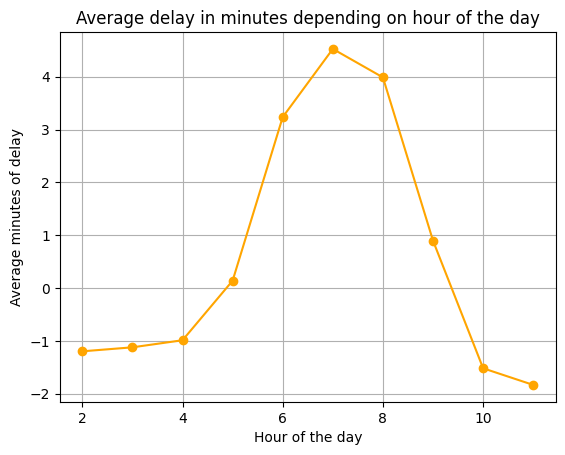

<Figure size 640x480 with 0 Axes>

In [31]:
# Visualization #1: Finding when avg delay is worst given hour of the day
plt.plot((data['departure_time_schedule'].dt.hour.unique()-12), hourly_mean, marker='o', color = 'orange')
plt.xlabel("Hour of the day")
plt.ylabel("Average minutes of delay")
plt.title("Average delay in minutes depending on hour of the day")
plt.grid(True)
plt.show()

plt.savefig("chart_1.png", dpi=300, bbox_inches='tight')

In [6]:
import altair as alt

#graph delay in minutes per hour based on stop_id
data['hour'] = data['departure_time_schedule'].dt.hour

# group the data by the stop_id and for each hour find the mean delay minutes
avg_delay = data.groupby(['stop_id', 'hour', 'direction_id_schedule' ])['delay_minutes'].mean().reset_index()
avg_delay

,stop_id,hour,direction_id_schedule,delay_minutes
0,70001,15,1,-4.409091
1,70001,16,1,-4.391667
2,70001,17,1,-3.913889
3,70001,18,1,-3.888462
4,70001,19,1,-0.190278
...,...,...,...,...
370,70279,19,1,5.975000
371,70279,20,1,2.268056
372,70279,21,1,0.316667
373,70279,22,1,-3.938333


In [26]:
chart = alt.Chart(avg_delay).mark_line(point=True).encode(
    x = alt.X('adjusted_hour:Q', title="Hour"),
    y = alt.Y('delay_minutes:Q', title="Average Delay (minutes)"),
    color = alt.Color('stop_id:N'),
    tooltip=["delay_minutes"]
).transform_calculate(
    adjusted_hour="datum.hour - 12"
).properties(
    width = 200,
    height = 200,
    title = "Average Delay in Minutes for each Stop"
)

chart

chart.save("chart_1.json")

In [27]:
# Visualization #2 (Interactive): Based on orange line stop, what is the average delay given the hour of the day
# select the stop_id you want to display
select_stop = alt.binding_radio(options=avg_delay["stop_id"].unique(), name="Stop Selection:")

selection = alt.selection_point(
    fields=['stop_id'], 
    bind=select_stop
)

main_chart = (alt.Chart(avg_delay).mark_line(point=True).transform_calculate(
    adjusted_hour="datum.hour - 12"
).encode(
    x=alt.X('adjusted_hour:Q', title="Hour"),
    y=alt.Y('delay_minutes:Q', title="Average Delay (min)"),
    color=alt.condition(
            selection,
            alt.Color('stop_id:N'),
            alt.value('lightgray')
    ),
    opacity=alt.condition(
            selection,
            alt.value(1.0),  
            alt.value(0.3)    
    ),
    tooltip=['stop_id', 'hour', 'delay_minutes']
).properties(
        width=350,
        height=250,
        title='Average Delay per Hour (All Stops)'
).add_params(selection)
)

selected_chart = (alt.Chart(avg_delay).transform_filter(selection).mark_line(point=True).transform_calculate(
    adjusted_hour="datum.hour - 12"
).encode(
        x=alt.X('adjusted_hour:Q', title="Hour"),
        y=alt.Y('delay_minutes:Q', title="Average Delay (min)")
).properties(
    width=350,
    height=250,
    title='Selected Stop Delay'
)
)

final_chart = main_chart | selected_chart

final_chart

final_chart.save("chart_2.json")

In [28]:
# Visualization #3: boxplot of average delay minutes for each hour

boxplot = alt.Chart(data).mark_boxplot().transform_calculate(
    adjusted_hour="datum.hour - 12"
).encode(
    x=alt.X('adjusted_hour:N', title='Hour', axis=alt.Axis(labelAngle=1)),
    y=alt.Y('delay_minutes:Q', title='Delayed minutes'),
    tooltip=['hour', 'delay_minutes']
).properties(
    width=350,
    height=250,
    title='Distribution of Delay over the Hours'
)

boxplot

boxplot.save("chart_3.json")

In [29]:
# histogram

histogram = alt.Chart(data).mark_bar().encode(
    x=alt.X('hour:Q', bin=True, title='Hour'),
    y=alt.Y('delay_minutes:Q', title='Delayed minutes'),
    tooltip=['hour', 'delay_minutes']
).properties(
    width=350,
    height=250,
    title='Distribution of Average Delay over the Hours'
)

histogram

histogram.save("chart_4.json")

In [12]:
# 2nd Data Source
# Goal is to compare ridership with delays
df = pd.read_csv("Fall_2024_MBTA_Rail_Ridership_by_Hour_Route_Line%2C_and_Stop.csv")
df.head()

,mode,season,route_id,route_name,dir_id,day_type_id,day_type_name,stop_name,parent_station,total_ons,total_offs,number_service_days,hour_of_service,average_ons,average_offs,average_flow,ObjectId
0,Heavy Rail,Fall 2024,Blue,Blue Line,EB,day_type_01,Weekday,Airport,place-aport,3358,7767,75,00:00:00,45,104,380,1
1,Heavy Rail,Fall 2024,Blue,Blue Line,EB,day_type_01,Weekday,Airport,place-aport,704,2121,75,01:00:00,9,28,95,2
2,Heavy Rail,Fall 2024,Blue,Blue Line,EB,day_type_01,Weekday,Airport,place-aport,145,351,75,02:00:00,2,5,17,3
3,Heavy Rail,Fall 2024,Blue,Blue Line,EB,day_type_01,Weekday,Airport,place-aport,1,2,75,03:00:00,0,0,0,4
4,Heavy Rail,Fall 2024,Blue,Blue Line,EB,day_type_01,Weekday,Airport,place-aport,3,3,75,04:00:00,0,0,0,5


In [13]:
# processing steps
# separate orange_line data from all predictions
df['hour_of_service'] = df['hour_of_service'].str[:2]
df['hour_of_service'] = df['hour_of_service'].astype('int')
orange_line_bool = df['route_id'] == 'Orange'
df_or = df.loc[orange_line_bool, :]
df_or

,mode,season,route_id,route_name,dir_id,day_type_id,day_type_name,stop_name,parent_station,total_ons,total_offs,number_service_days,hour_of_service,average_ons,average_offs,average_flow,ObjectId
1632,Heavy Rail,Fall 2024,Orange,Orange Line,NB,day_type_01,Weekday,Assembly,place-astao,375,1331,60,0,6,22,193,1633
1633,Heavy Rail,Fall 2024,Orange,Orange Line,NB,day_type_01,Weekday,Assembly,place-astao,121,330,60,1,2,6,40,1634
1634,Heavy Rail,Fall 2024,Orange,Orange Line,NB,day_type_01,Weekday,Assembly,place-astao,31,56,60,2,1,1,8,1635
1635,Heavy Rail,Fall 2024,Orange,Orange Line,NB,day_type_01,Weekday,Assembly,place-astao,0,0,60,3,0,0,0,1636
1636,Heavy Rail,Fall 2024,Orange,Orange Line,NB,day_type_01,Weekday,Assembly,place-astao,0,1,60,4,0,0,0,1637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4716,Heavy Rail,Fall 2024,Orange,Orange Line,SB,day_type_03,Sunday,Sullivan Square,place-sull,996,287,13,19,77,22,416,4717
4718,Heavy Rail,Fall 2024,Orange,Orange Line,SB,day_type_03,Sunday,Sullivan Square,place-sull,897,182,13,20,69,14,320,4719
4720,Heavy Rail,Fall 2024,Orange,Orange Line,SB,day_type_03,Sunday,Sullivan Square,place-sull,936,190,13,21,72,15,271,4721
4722,Heavy Rail,Fall 2024,Orange,Orange Line,SB,day_type_03,Sunday,Sullivan Square,place-sull,829,158,13,22,64,12,211,4723


In [14]:
# group by hour and stop
df_or_grouped = df_or.groupby(['hour_of_service', 'stop_name', 'dir_id']).agg({
    'total_ons' : 'mean',
    'total_offs' : 'mean',
    'average_flow': 'mean'})
df_or_grouped.reset_index(inplace = True)

df_or_grouped = df_or_grouped.rename(columns={
    'total_ons': 'avg_total_ons',
    'total_offs': 'avg_total_offs',
    'average_flow': 'avg_passenger_flow',
    'dir_id': 'direction'
})
df_or_grouped

,hour_of_service,stop_name,direction,avg_total_ons,avg_total_offs,avg_passenger_flow
0,0,Assembly,NB,206.666667,689.333333,215.000000
1,0,Assembly,SB,430.333333,39.333333,44.333333
2,0,Back Bay,NB,2227.333333,227.000000,180.000000
3,0,Back Bay,SB,993.000000,782.000000,208.333333
4,0,Chinatown,NB,714.333333,145.333333,234.000000
...,...,...,...,...,...,...
946,23,Sullivan Square,SB,1569.000000,232.666667,167.000000
947,23,Tufts Medical Center,NB,2184.000000,385.333333,468.666667
948,23,Tufts Medical Center,SB,963.000000,912.333333,487.666667
949,23,Wellington,NB,212.333333,3530.666667,422.000000


In [15]:
print(sorted(df_or_grouped['stop_name'].unique().tolist()))

['Assembly', 'Back Bay', 'Chinatown', 'Community College', 'Downtown Crossing', 'Forest Hills', 'Green Street', 'Haymarket', 'Jackson Square', 'Malden Center', 'Massachusetts Avenue', 'North Station', 'Oak Grove', 'Roxbury Crossing', 'Ruggles', 'State', 'Stony Brook', 'Sullivan Square', 'Tufts Medical Center', 'Wellington']


In [16]:
stop_ids = {
    70001: 'Forest Hills', 70002: 'Green Street', 70003: 'Green Street', 70004: 'Stony Brook', 70005: 'Stony Brook',
    70006: 'Jackson Square', 70007: 'Jackson Square', 70008: 'Roxbury Crossing', 70009: 'Roxbury Crossing', 70010: 'Ruggles',
    70011: 'Ruggles', 70012: 'Massachusetts Avenue', 70013: 'Massachusetts Avenue', 70014: 'Back Bay', 70015: 'Back Bay', 
    70016: 'Tufts Medical Center', 70017: 'Tufts Medical Center',
    70018: 'Chinatown', 70019: 'Chinatown', 70020: 'Downtown Crossing', 70021: 'Downtown Crossing', 70022: 'State',
    70023: 'State', 70024: 'Haymarket', 70025: 'Haymarket', 70026: 'North Station', 70027: 'North Station', 
    70028: 'Community College', 70029: 'Community College', 70030: 'Sullivan Square', 70031: 'Sullivan Square',
    70032: 'Wellington', 70033: 'Wellington', 70034: 'Malden Center', 70035: 'Malden Center', 70036: 'Oak Grove',
    70278: 'Assembly', 70279: 'Assembly'
    
}

# Create a new column with stop_ids for merging in avg_delay
avg_delay['stop_name'] = avg_delay['stop_id'].map(stop_ids)

# create new column to merge on direction as well
directions = {1: 'NB', 0: 'SB'} 
avg_delay['direction'] = avg_delay['direction_id_schedule'].map(directions)
avg_delay

,stop_id,hour,direction_id_schedule,delay_minutes,stop_name,direction
0,70001,15,1,-4.409091,Forest Hills,NB
1,70001,16,1,-4.391667,Forest Hills,NB
2,70001,17,1,-3.913889,Forest Hills,NB
3,70001,18,1,-3.888462,Forest Hills,NB
4,70001,19,1,-0.190278,Forest Hills,NB
...,...,...,...,...,...,...
370,70279,19,1,5.975000,Assembly,NB
371,70279,20,1,2.268056,Assembly,NB
372,70279,21,1,0.316667,Assembly,NB
373,70279,22,1,-3.938333,Assembly,NB


In [17]:
# only including flow data that would be included in delay_data
in_avg_delay_bool = df_or_grouped['hour_of_service'] >= 12
df_or_grouped = df_or_grouped.loc[in_avg_delay_bool, :]
df_or_grouped


,hour_of_service,stop_name,direction,avg_total_ons,avg_total_offs,avg_passenger_flow
471,12,Assembly,NB,1012.333333,4914.333333,426.000000
472,12,Assembly,SB,5085.000000,1229.333333,783.666667
473,12,Back Bay,NB,7239.333333,5142.666667,1051.333333
474,12,Back Bay,SB,2959.333333,8563.333333,622.333333
475,12,Chinatown,NB,3655.000000,2637.333333,1080.333333
...,...,...,...,...,...,...
946,23,Sullivan Square,SB,1569.000000,232.666667,167.000000
947,23,Tufts Medical Center,NB,2184.000000,385.333333,468.666667
948,23,Tufts Medical Center,SB,963.000000,912.333333,487.666667
949,23,Wellington,NB,212.333333,3530.666667,422.000000


In [18]:
# merging traffic flow data with delay data
avg_delay['hr_pm'] = (avg_delay['hour'].astype('int'))-12
df_or_grouped['hr_pm'] = (df_or_grouped['hour_of_service'].astype('int'))-12

full = df_or_grouped.merge(
    avg_delay, 
    left_on=['hr_pm', 'stop_name', 'direction'], 
    right_on=['hr_pm', 'stop_name', 'direction'], 
    how='right'
)
full.drop(['hour_of_service', 'hour'], axis = 1, inplace = True)

# grouping to combine inbound and outbound trains, focusing on stop as a whole
full = full.groupby(['stop_name', 'hr_pm', 'direction'])[['avg_total_ons', 'avg_total_offs', 'avg_passenger_flow', 'delay_minutes']].mean().reset_index()
full.to_csv('processed_ridership_delay.csv', index=False)
full

/var/folders/18/q3lw8jbd427bd2c36t6m5c740000gn/T/ipykernel_1626/548611219.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_or_grouped['hr_pm'] = (df_or_grouped['hour_of_service'].astype('int'))-12


,stop_name,hr_pm,direction,avg_total_ons,avg_total_offs,avg_passenger_flow,delay_minutes
0,Assembly,2,SB,6479.000000,1368.333333,880.666667,1.816667
1,Assembly,3,NB,1780.333333,7749.000000,813.333333,-3.117949
2,Assembly,3,SB,8216.666667,1504.666667,883.666667,0.773611
3,Assembly,4,NB,2250.666667,8721.000000,1121.000000,-3.038889
4,Assembly,4,SB,9428.333333,1378.000000,850.333333,1.020833
...,...,...,...,...,...,...,...
370,Wellington,9,SB,1308.000000,119.666667,157.000000,3.065152
371,Wellington,10,NB,306.000000,4721.000000,491.666667,-3.948333
372,Wellington,10,SB,1086.333333,107.000000,128.000000,1.805556
373,Wellington,11,NB,212.333333,3530.666667,422.000000,-5.235185


In [30]:
# Visualization 4 (Interactive) (Altair)

input_radio = alt.binding_radio(options = [None] + ['Forest Hills', 'Green Street', 'Stony Brook', 'Jackson Square',
             'Roxbury Crossing', 'Ruggles', 'Massachusetts Avenue', 'Back Bay',
             'Tufts Medical Center', 'Chinatown', 'Downtown Crossing', 'State',
             'Haymarket', 'North Station', 'Community College', 'Sullivan Square',
             'Wellington', 'Malden Center', 'Oak Grove', 'Assembly'],
    labels = ['All'] + ['Forest Hills', 'Green Street', 'Stony Brook', 'Jackson Square',
            'Roxbury Crossing', 'Ruggles', 'Massachusetts Avenue', 'Back Bay',
            'Tufts Medical Center', 'Chinatown', 'Downtown Crossing', 'State',
            'Haymarket', 'North Station', 'Community College', 'Sullivan Square',
            'Wellington', 'Malden Center', 'Oak Grove', 'Assembly'],
    name = "Stop: ")

selection_line = alt.selection_point(bind=input_radio, fields=['stop_name'])

selection_direction = alt.selection_point(fields=['direction'])

flow_slider = alt.binding_range(min = 0, max =  3000, step = 10, name = "Average Hourly Passenger Flow: ")
selection_flow = alt.param(value = 100, bind = flow_slider)

chart = alt.Chart(full).mark_circle().encode(
    x = alt.X('hr_pm:Q', title = 'Hour'),
    y = alt.Y('delay_minutes:Q', title = 'Delay (minutes)'),
    color = alt.Color('stop_name:N', title = 'Stop Name'),
    size = 'avg_passenger_flow:Q',
    opacity = alt.condition(selection_direction, alt.value(1), alt.value(0.1)), 
    tooltip = ['stop_name', 'avg_passenger_flow', 'avg_total_ons', 'avg_total_offs', 'delay_minutes']
).properties(
    title = "Average Delay (Early) in Arrival Time by Hour",
    width = 500,
    height = 400
).add_params(
    selection_line,
    selection_flow
).transform_filter(
    alt.datum.avg_passenger_flow <= selection_flow
).transform_filter(
    selection_line
)

legend = alt.Chart(full).mark_rect().encode(
    x = alt.X('direction:N'),
        color=alt.condition(selection_direction, alt.value('gold'), alt.value('lightgray'))
).add_params(
    selection_direction
)

final_chart_lol = chart | legend

final_chart_lol

final_chart_lol.save("Chart_4.json")

In [23]:
line = 'Forest Hills'
line_bool = full['stop_name'] == line
full_test = full.loc[line_bool, :]
print(full_test['delay_minutes'].sum() )

-34.20272921522922
